In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [8]:
df=pd.read_csv('complaints.csv', on_bad_lines='skip')
print(df.shape)
print(df.columns.tolist())
print(df.head(2))

(2023066, 11)
['Unnamed: 0', 'product_5', 'narrative', 'Product', 'Date received', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Timely response?']
   Unnamed: 0         product_5  \
0         234  Credit Reporting   
1         240   Debt Collection   

                                           narrative  \
0  Dear Possible Financial Inc you guyss aree rep...   
1  XXXX XXXX XXXX ( debt collector ), sent my boy...   

                                             Product Date received  \
0  Credit reporting or other personal consumer re...    2024-07-27   
1                                    Debt collection    2024-07-27   

        Sub-product                                              Issue  \
0  Credit reporting               Incorrect information on your report   
1     I do not know  Threatened to contact someone or share informa...   

                                 Sub-issue                 Company State  \
0            Account information incorrect  Possible Fi

In [9]:
df_sample=df.sample(n=50000, random_state=42)
df_sample.to_csv('complaints_sample.csv', index=False)
df=df_sample
print("Trimmed dataset shape:", df.shape)

Trimmed dataset shape: (50000, 11)


## Basic Cleaning:

In [11]:
#Drop unnamed index column and rename for convenience
df.drop(columns=['Unnamed: 0'], inplace=True)
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

#Check nulls
print(df.isnull().sum())
print("\nDate range:")
df['date_received'] = pd.to_datetime(df['date_received'])
print(df['date_received'].min(), "to", df['date_received'].max())

product_5              0
narrative              0
product                0
date_received          0
sub-product         1294
issue                  0
sub-issue           5698
company                0
state                183
timely_response?       0
dtype: int64

Date range:
2015-03-19 00:00:00 to 2024-07-29 00:00:00


In [15]:
#Clean nulls and standardize
df['sub-product']=df['sub-product'].fillna('Unknown')
df['sub-issue']=df['sub-issue'].fillna('Unknown')
df['state']=df['state'].fillna('Unknown')

#Extract year and month for time series analysis
df['year']=df['date_received'].dt.year
df['month']=df['date_received'].dt.month
df['year_month']=df['date_received'].dt.to_period('M')

print("Cleaned Shape:", df.shape)
print(df['product_5'].value_counts())

Cleaned Shape: (50000, 13)
product_5
Credit Reporting              29910
Debt Collection                6579
Loans                          5653
Credit Card Services           4004
Bank Accounts and Services     3854
Name: count, dtype: int64


## Core Analysis:

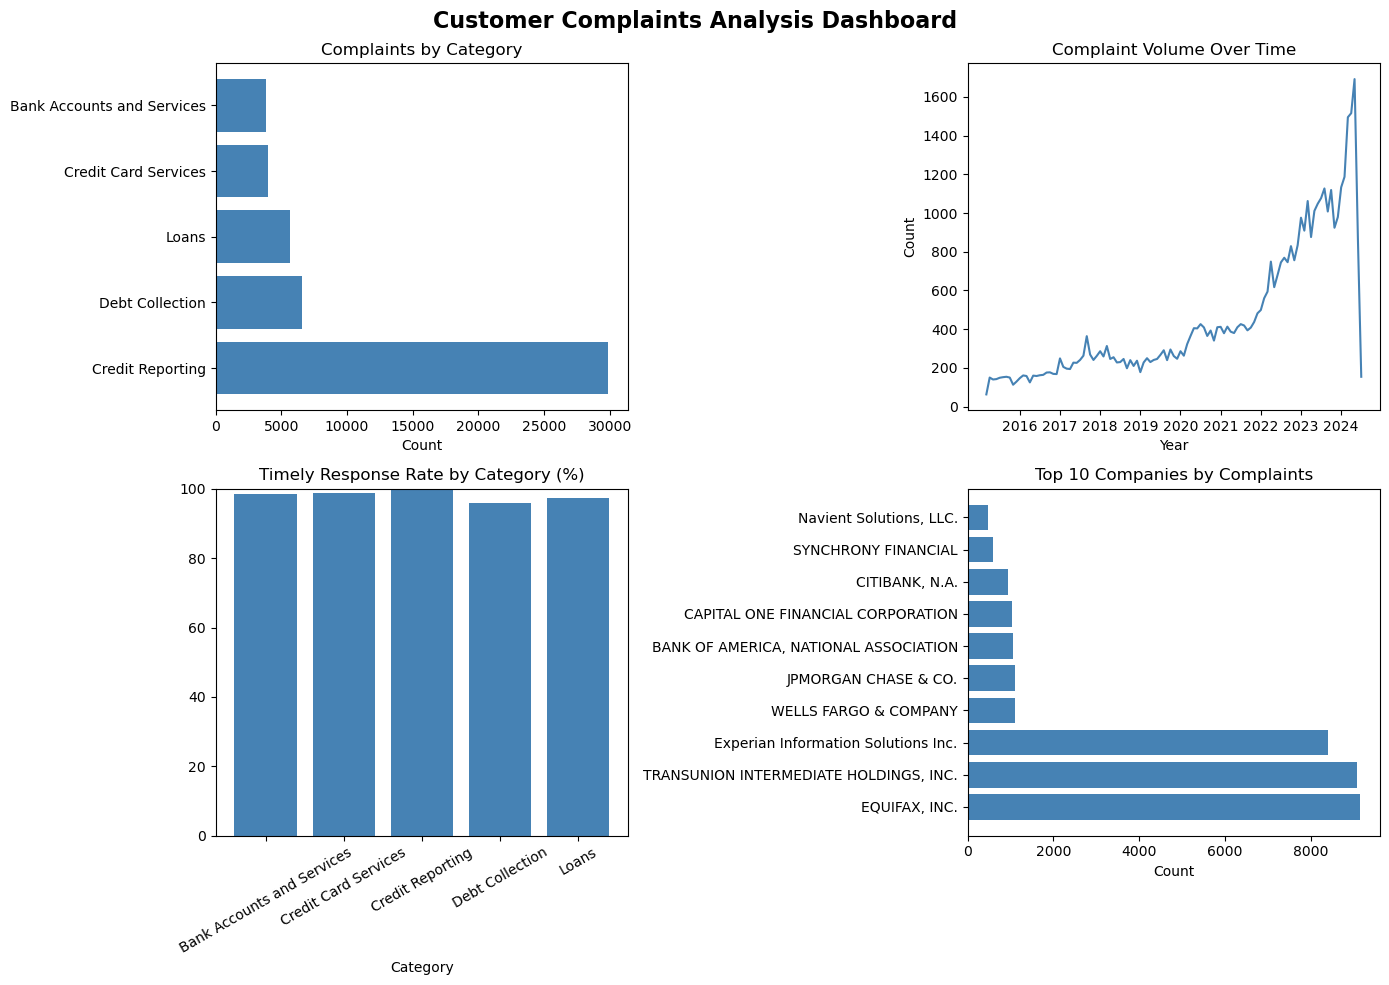

Dashboard saved.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. Complaint volume by category
fig, axes=plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Complaints Analysis Dashboard', fontsize=16, fontweight='bold')

#Category distribution
category_counts=df['product_5'].value_counts()
axes[0,0].barh(category_counts.index, category_counts.values, color='steelblue')
axes[0,0].set_title('Complaints by Category')
axes[0,0].set_xlabel('Count')

#Complaints over time
monthly=df.groupby('year_month').size().reset_index(name='count')
monthly['year_month']=monthly['year_month'].astype(str)

axes[0,1].plot(monthly['year_month'], monthly['count'], color='steelblue', linewidth=1.5)
axes[0,1].set_title('Complaint Volume Over Time')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Count')

#Show only January of each year as tick
jan_ticks=[i for i, ym in enumerate(monthly['year_month']) if ym.endswith('-01')]
axes[0,1].set_xticks(jan_ticks)
axes[0,1].set_xticklabels([monthly['year_month'].iloc[i][:4] for i in jan_ticks], rotation=0)

#Timely response rate by category
response=df.groupby('product_5')['timely_response?'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
response.columns=['product_5', 'timely_pct']
axes[1,0].bar(response['product_5'], response['timely_pct'], color='steelblue')
axes[1,0].set_title('Timely Response Rate by Category (%)')
axes[1,0].set_xlabel('Category')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_ylim(0, 100)

#Top 10 companies by complaints
top_companies=df['company'].value_counts().head(10)
axes[1,1].barh(top_companies.index, top_companies.values, color='steelblue')
axes[1,1].set_title('Top 10 Companies by Complaints')
axes[1,1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('complaints_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

In [19]:
#Convert Period column to string before loading into SQLite
df['year_month']=df['year_month'].astype(str)

#Reload into SQLite
conn=sqlite3.connect(':memory:')
df.to_sql('complaints', conn, index=False, if_exists='replace')

queries={
    'Top 5 Issues per Category': """
        SELECT product_5, issue, COUNT(*) as count
        FROM complaints
        GROUP BY product_5, issue
        ORDER BY product_5, count DESC
        LIMIT 20
    """,
    'Annual Complaint Growth': """
        SELECT year, COUNT(*) as total_complaints,
        ROUND(100.0*(COUNT(*) - LAG(COUNT(*)) OVER (ORDER BY year)) / LAG(COUNT(*)) OVER (ORDER BY year), 2) as yoy_growth
        FROM complaints
        GROUP BY year
        ORDER BY year
    """
}

for name, query in queries.items():
    print(f"\n--- {name} ---")
    print(pd.read_sql_query(query, conn))


--- Top 5 Issues per Category ---
                     product_5  \
0   Bank Accounts and Services   
1   Bank Accounts and Services   
2   Bank Accounts and Services   
3   Bank Accounts and Services   
4   Bank Accounts and Services   
5   Bank Accounts and Services   
6   Bank Accounts and Services   
7   Bank Accounts and Services   
8   Bank Accounts and Services   
9   Bank Accounts and Services   
10  Bank Accounts and Services   
11  Bank Accounts and Services   
12  Bank Accounts and Services   
13  Bank Accounts and Services   
14  Bank Accounts and Services   
15  Bank Accounts and Services   
16  Bank Accounts and Services   
17  Bank Accounts and Services   
18  Bank Accounts and Services   
19  Bank Accounts and Services   

                                                issue  count  
0                                 Managing an account   1351  
1                                       Fraud or scam    396  
2                                  Closing an account    362 

## Statistical Analysis:

In [20]:
#Statistical Analysis
from scipy import stats

#1. Hypothesis test: Is Credit Reporting response rate significantly different from others?
cr_response=(df[df['product_5']=='Credit Reporting']['timely_response?']=='Yes').astype(int)
other_response=(df[df['product_5']!='Credit Reporting']['timely_response?']=='Yes').astype(int)

t_stat, p_value=stats.ttest_ind(cr_response, other_response)
print("=== Hypothesis Test: Credit Reporting vs Others ===")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant difference: {p_value < 0.05}")

#2. Yearly trend - linear regression to quantify growth
from sklearn.linear_model import LinearRegression
yearly=df.groupby('year').size().reset_index(name='count')
X=yearly['year'].values.reshape(-1, 1)
y=yearly['count'].values

model=LinearRegression()
model.fit(X, y)
print(f"\n=== Complaint Growth Trend ===")
print(f"Average yearly increase: {model.coef_[0]:.0f} complaints/year")
print(f"R² score: {model.score(X, y):.4f}")

#3. Top states by complaint volume
print("\n=== Top 10 States by Complaint Volume ===")
print(df['state'].value_counts().head(10))

=== Hypothesis Test: Credit Reporting vs Others ===
T-statistic: 21.2927
P-value: 0.0000
Significant difference: True

=== Complaint Growth Trend ===
Average yearly increase: 1008 complaints/year
R² score: 0.7822

=== Top 10 States by Complaint Volume ===
state
FL    5908
CA    5817
TX    5362
GA    3628
NY    3082
IL    2305
PA    2017
NC    1732
NJ    1564
OH    1282
Name: count, dtype: int64


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

#Prepare text data
X=df['narrative'].fillna('')
y=df['product_5']

#TF-IDF vectorization
tfidf=TfidfVectorizer(max_features=2000, stop_words='english')
X_tfidf=tfidf.fit_transform(X)

#Train/test split
X_train, X_test, y_train, y_test=train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

#Train classifier
clf=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

#Evaluate
y_pred=clf.predict(X_test)
print(classification_report(y_test, y_pred))

                            precision    recall  f1-score   support

Bank Accounts and Services       0.81      0.84      0.82       753
      Credit Card Services       0.82      0.64      0.72       808
          Credit Reporting       0.88      0.96      0.92      6079
           Debt Collection       0.80      0.62      0.70      1238
                     Loans       0.85      0.76      0.80      1122

                  accuracy                           0.86     10000
                 macro avg       0.84      0.77      0.80     10000
              weighted avg       0.86      0.86      0.86     10000



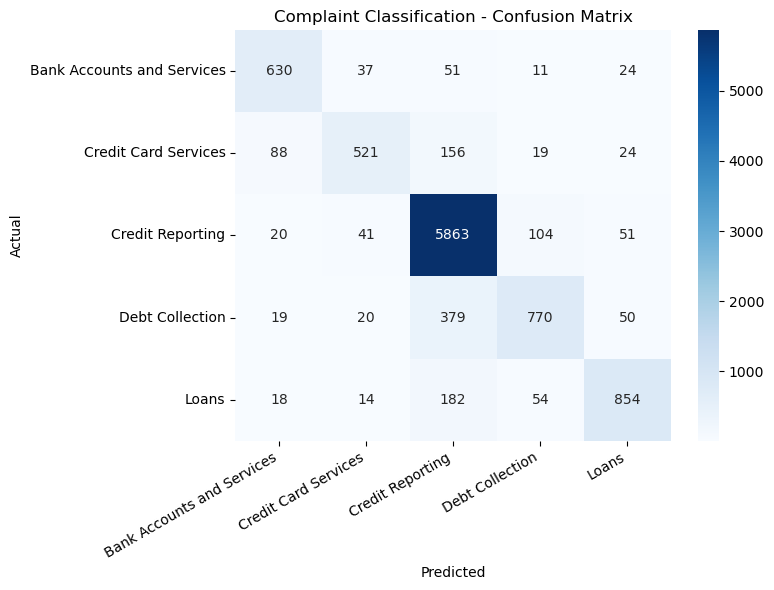

Saved.


In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

#Confusion matrix
cm=confusion_matrix(y_test, y_pred)
labels=clf.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Complaint Classification - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")